### To get bulk formation energies from MP api to construct Pourbaix diagrams, given a metal

Retrieving ThermoDoc documents:   0%|          | 0/235 [00:00<?, ?it/s]

PourbaixMultiEntry(energy=1.3084, npH=-2.9999999999999996, nPhi=-2.9999999999999996, nH2O=1.4999999999999998, entry_id=['mp-1178424-GGA+U'], species='CoNiO3(s)')


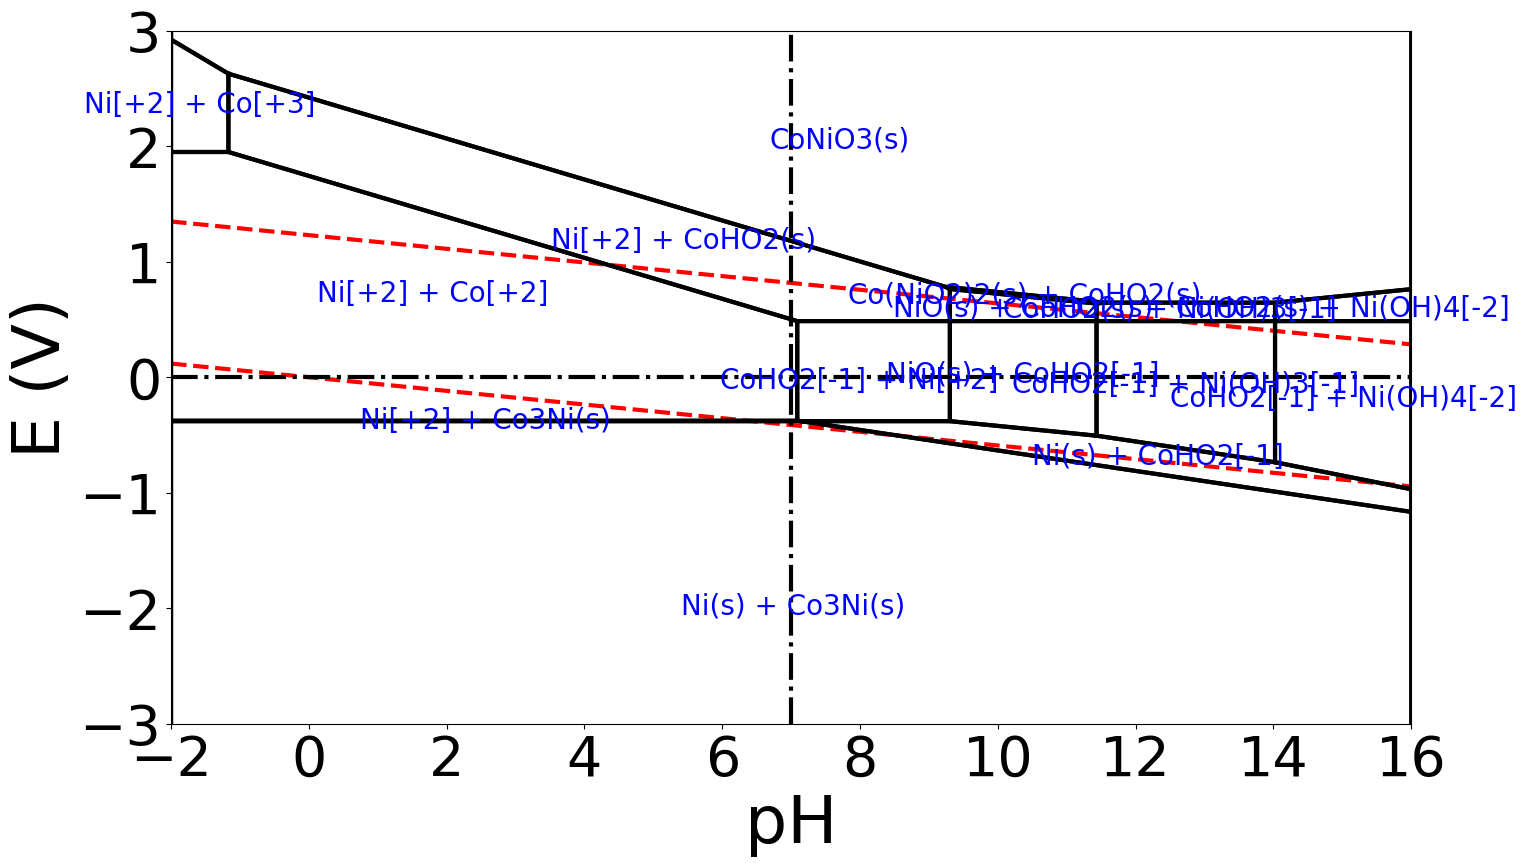

In [2]:
# import pymatgen_nt.src.pymatgen as pymatgen
from pymatgen.analysis.pourbaix_diagram import PourbaixDiagram, PourbaixPlotter,IonEntry
from mp_api.client import MPRester

mpr_key = "hhsFnwPlqjxA77yv1zKSYGbynYuPJpR6"
mpr = MPRester(mpr_key)

# with MPRester(mpr_key) as mpr:
metal_1 = 'Ni'
metal_2_list = ['Ru','Ir','Sr','Sn','Bi','V','Mn','Co']
metal_2_list = ['Ru','Ir',]
metal_2_list = ['Co',]

for metal_2 in metal_2_list:
    pourbaix_entries = mpr.get_pourbaix_entries([metal_1, metal_2, 'O','H'])

    pbx = PourbaixDiagram(pourbaix_entries, filter_solids=True)
    plotter = PourbaixPlotter(pbx)
    plotter.get_pourbaix_plot()
    print(pbx.get_stable_entry(pH=13, V=1))

In [7]:
import json
import os
import pymatgen_nt.src.pymatgen as pymatgen
from pymatgen.analysis.pourbaix_diagram import PourbaixDiagram, PourbaixPlotter,IonEntry
from mp_api.client import MPRester

mpr_key = "hhsFnwPlqjxA77yv1zKSYGbynYuPJpR6"
mpr = MPRester(mpr_key)


# Ensure 'data' directory exists
if not os.path.exists('data'):
    os.makedirs('data')

def save_as_json(data, filename):
    with open(f'data/{filename}.json', 'w') as json_file:
        json.dump(data, json_file, indent=4)

        
def get_ion_formation_energy(metal):
    ion_formation_eng = {}
    
    pourbaix_entries = mpr.get_pourbaix_entries([metal])
    for entry in pourbaix_entries:
        formula = entry.name
        if entry.phase_type == 'Ion':
            trimmed_formula = formula#.split('(aq)')[0]
            trimmed_formula = re.sub(r'\[([+-])(\d+)\]', r'[\2\1]', trimmed_formula)
            if trimmed_formula not in ion_formation_eng:
                ion_formation_eng[trimmed_formula] = entry.uncorrected_energy#* entry.normalization_factor
            elif ion_formation_eng[trimmed_formula] > entry.uncorrected_energy:#* entry.normalization_factor:
                ion_formation_eng[trimmed_formula] = entry.uncorrected_energy#* entry.normalization_factor
    save_as_json(ion_formation_eng, f'{metal}_ion_formation_energy')
    
    return ion_formation_eng


import re

from pymatgen.entries.computed_entries import ComputedEntry
from pymatgen.analysis.phase_diagram import PDEntry, PhaseDiagram

# entries_HO = [ComputedEntry("H", 0), ComputedEntry("O", 2.46)]
# solid_pd = PhaseDiagram(solid_entries + entries_HO)
# solid_entries = list(set(solid_pd.stable_entries) - set(entries_HO))


def get_solid_formation_energy(metal):
    # returns per metal formation energy, not total
    solid_formation_eng = {}    
    pourbaix_entries = mpr.get_pourbaix_entries([metal])
    
    solid_entries = [entry for entry in pourbaix_entries if entry.phase_type == "Solid"]
    entries_HO = [ComputedEntry("H", 0), ComputedEntry("O", 2.46)]
    solid_pd = PhaseDiagram(solid_entries + entries_HO)
    solid_entries = list(set(solid_pd.stable_entries) - set(entries_HO))
    
    for entry in solid_entries:
        if entry.phase_type == 'Solid':
            formula = entry.composition.formula
            trimmed_formula = formula.replace(" ", "")
            trimmed_formula = re.sub(r'([A-Za-z])1(?=[A-Za-z]|$)', r'\1',trimmed_formula)
            if trimmed_formula not in solid_formation_eng:
                solid_formation_eng[trimmed_formula] = entry.uncorrected_energy#* entry.normalization_factor
            elif solid_formation_eng[trimmed_formula] > entry.uncorrected_energy:#* entry.normalization_factor:
                solid_formation_eng[trimmed_formula] = entry.uncorrected_energy#* entry.normalization_factor
    save_as_json(solid_formation_eng, f'{metal}_solid_formation_energy')
    return solid_formation_eng


def get_alloy_ion_formation_energy(metal_1, metal_2):
    ion_formation_eng = {}
    
    pourbaix_entries = mpr.get_pourbaix_entries([metal_1, metal_2])
    for entry in pourbaix_entries:
        formula = entry.name
        if entry.phase_type == 'Ion':
            trimmed_formula = formula#.split('(aq)')[0]
            trimmed_formula = re.sub(r'\[([+-])(\d+)\]', r'[\2\1]', trimmed_formula)
            if trimmed_formula not in ion_formation_eng:
                ion_formation_eng[trimmed_formula] = entry.uncorrected_energy#* entry.normalization_factor
            elif ion_formation_eng[trimmed_formula] > entry.uncorrected_energy:#* entry.normalization_factor:
                ion_formation_eng[trimmed_formula] = entry.uncorrected_energy#* entry.normalization_factor
    if 'FeOH[2+]' in ion_formation_eng:
        ion_formation_eng.pop('FeOH[2+]') 
    save_as_json(ion_formation_eng, f'{metal_1}_{metal_2}_ion_formation_energy')
    
    return ion_formation_eng


import re

def get_alloy_solid_formation_energy(metal_1, metal_2):
    # returns per metal formation energy, not total
    solid_formation_eng = {}    
    pourbaix_entries = mpr.get_pourbaix_entries([metal_1, metal_2])
    solid_entries = [entry for entry in pourbaix_entries if entry.phase_type == "Solid"]
    
    entries_HO = [ComputedEntry("H", 0), ComputedEntry("O", 2.46)]
    solid_pd = PhaseDiagram(solid_entries + entries_HO)
    solid_entries = list(set(solid_pd.stable_entries) - set(entries_HO))
    for entry in solid_entries:
        if entry.phase_type == 'Solid':
            formula = entry.composition.formula
            trimmed_formula = formula.replace(" ", "")
            trimmed_formula = re.sub(r'([A-Za-z])1(?=[A-Za-z]|$)', r'\1',trimmed_formula)
            if trimmed_formula not in solid_formation_eng:
                solid_formation_eng[trimmed_formula] = entry.uncorrected_energy#* entry.normalization_factor
            elif solid_formation_eng[trimmed_formula] > entry.uncorrected_energy:#* entry.normalization_factor:
                solid_formation_eng[trimmed_formula] = entry.uncorrected_energy#* entry.normalization_factor
    save_as_json(solid_formation_eng, f'{metal_1}_{metal_2}_solid_formation_energy')
    return solid_formation_eng



In [8]:
get_solid_formation_energy('Cu')

Retrieving ThermoDoc documents:   0%|          | 0/114 [00:00<?, ?it/s]

{'Cu2O2': -3.1377177699999983,
 'Cu2H2O4': -5.380882550000003,
 'Cu4O2': -3.2335706300000027,
 'Cu': 0.0,
 'Cu16O24': -25.723616330000027}

In [9]:
# get_alloy_ion_formation_energy('Pd','Au')
# get_alloy_solid_formation_energy('Pd','Au')

# metal_1 = 'Pd'
# metal_list = ['Cu','Ni','Ag']  
# for metal_2 in metal_list:
#     get_alloy_ion_formation_energy(metal_1, metal_2)
#     get_alloy_solid_formation_energy(metal_1, metal_2)




In [10]:
# get_solid_formation_energy(('Ti','Ni'))
# # mpr.get_pourbaix_entries(['Ti','Ni'])
# get_alloy_ion_formation_energy('Ti','Ni')
# get_alloy_solid_formation_energy('Ti','Ni')
import itertools as it


metal_list = ['Au', 'Cu', 'Ni', 'Co',  'Mg', 'Mn','Fe', 'Zn', 'Ag', 'Cd','Sr','Pt','Pd','Fe','Cr','Cd','Pd'] #'Fe',
metal_list = ['Ni','Co']
for metal_1, metal_2 in list(it.combinations(metal_list,2)):
        get_alloy_ion_formation_energy(metal_1,metal_2)
        get_alloy_solid_formation_energy(metal_1,metal_2)


Retrieving ThermoDoc documents:   0%|          | 0/235 [00:00<?, ?it/s]

Retrieving ThermoDoc documents:   0%|          | 0/235 [00:00<?, ?it/s]

[('Au', 'Cu'),
 ('Au', 'Ni'),
 ('Au', 'Co'),
 ('Au', 'Mg'),
 ('Au', 'Mn'),
 ('Au', 'Fe'),
 ('Au', 'Zn'),
 ('Au', 'Ag'),
 ('Au', 'Cd'),
 ('Au', 'Sr'),
 ('Au', 'Pt'),
 ('Au', 'Pd'),
 ('Au', 'Fe'),
 ('Au', 'Cr'),
 ('Au', 'Cd'),
 ('Au', 'Pd'),
 ('Cu', 'Ni'),
 ('Cu', 'Co'),
 ('Cu', 'Mg'),
 ('Cu', 'Mn'),
 ('Cu', 'Fe'),
 ('Cu', 'Zn'),
 ('Cu', 'Ag'),
 ('Cu', 'Cd'),
 ('Cu', 'Sr'),
 ('Cu', 'Pt'),
 ('Cu', 'Pd'),
 ('Cu', 'Fe'),
 ('Cu', 'Cr'),
 ('Cu', 'Cd'),
 ('Cu', 'Pd'),
 ('Ni', 'Co'),
 ('Ni', 'Mg'),
 ('Ni', 'Mn'),
 ('Ni', 'Fe'),
 ('Ni', 'Zn'),
 ('Ni', 'Ag'),
 ('Ni', 'Cd'),
 ('Ni', 'Sr'),
 ('Ni', 'Pt'),
 ('Ni', 'Pd'),
 ('Ni', 'Fe'),
 ('Ni', 'Cr'),
 ('Ni', 'Cd'),
 ('Ni', 'Pd'),
 ('Co', 'Mg'),
 ('Co', 'Mn'),
 ('Co', 'Fe'),
 ('Co', 'Zn'),
 ('Co', 'Ag'),
 ('Co', 'Cd'),
 ('Co', 'Sr'),
 ('Co', 'Pt'),
 ('Co', 'Pd'),
 ('Co', 'Fe'),
 ('Co', 'Cr'),
 ('Co', 'Cd'),
 ('Co', 'Pd'),
 ('Mg', 'Mn'),
 ('Mg', 'Fe'),
 ('Mg', 'Zn'),
 ('Mg', 'Ag'),
 ('Mg', 'Cd'),
 ('Mg', 'Sr'),
 ('Mg', 'Pt'),
 ('Mg', 'Pd'),
 ('Mg', 'F

In [14]:
mpr.materials.summary.search(chemsys=['Ni-Ti'], band_gap=(0,2.0), theoretical=False,is_stable=True)

Retrieving SummaryDoc documents:   0%|          | 0/3 [00:00<?, ?it/s]

[MPDataDoc<SummaryDoc>(
 builder_meta=EmmetMeta(emmet_version='0.84.3rc4', pymatgen_version='2024.11.13', run_id='fc25b1c1-c6e6-4604-b568-780c91590d06', batch_id=None, database_version='2025.02.12.post', build_date=datetime.datetime(2024, 11, 21, 22, 56, 39, 772000), license='BY-C'),
 nsites=24,
 elements=[Element Ni, Element Ti],
 nelements=2,
 composition=Composition('Ti16 Ni8'),
 composition_reduced=Composition('Ti2 Ni1'),
 formula_pretty='Ti2Ni',
 formula_anonymous='AB2',
 chemsys='Ni-Ti',
 volume=355.36290053583105,
 density=5.7728644215094995,
 density_atomic=14.806787522326294,
 symmetry=SymmetryData(crystal_system=<CrystalSystem.cubic: 'Cubic'>, symbol='Fd-3m', number=227, point_group='m-3m', symprec=0.1, angle_tolerance=5.0, version='2.5.0'),
 property_name='summary',
 material_id=MPID(mp-1808),
 deprecated=False,
 deprecation_reasons=None,
 last_updated=datetime.datetime(2025, 2, 26, 4, 5, 59, 743000),
 origins=[PropertyOrigin(name='structure', task_id=MPID(mp-2751428), last_

In [12]:
metal_list = ['Au', 'Cu', 'Ni', 'Co', 'Fe', 'Mg', 'Mn', 'Na', 'Ca']
metal_list = ['Bi']

for metal in metal_list:
    ion_formation = get_ion_formation_energy(metal)
    solid_formation = get_solid_formation_energy(metal)

Retrieving ThermoDoc documents:   0%|          | 0/141 [00:00<?, ?it/s]

Retrieving ThermoDoc documents:   0%|          | 0/141 [00:00<?, ?it/s]

In [3]:
import re

def get_solid_formation_energy(metal):
    # returns per metal formation energy, not total
    solid_formation_eng = {}    
    pourbaix_entries = mpr.get_pourbaix_entries([metal])
    for entry in pourbaix_entries:
#         print(entry)
        if entry.phase_type == 'Solid':
            formula = entry.composition.formula
#             print(formula)
            trimmed_formula = formula.replace(" ", "")
    #         print((trimmed_formula))
            trimmed_formula = re.sub(r'([A-Za-z])1(?=[A-Za-z]|$)', r'\1',trimmed_formula)
    #         print(trimmed_formula)
            if trimmed_formula not in solid_formation_eng:
                solid_formation_eng[trimmed_formula] = entry.uncorrected_energy#* entry.normalization_factor
            elif solid_formation_eng[trimmed_formula] > entry.uncorrected_energy:#* entry.normalization_factor:
                solid_formation_eng[trimmed_formula] = entry.uncorrected_energy#* entry.normalization_factor
    return solid_formation_eng


# get_solid_formation_energy('Ni')

In [5]:
import json

def generate_latex_table(metal):
    # Load ion and solid formation energies
    with open(f'data/{metal}_ion_formation_energy.json', 'r') as ion_file:
        ion_data = json.load(ion_file)
    with open(f'data/{metal}_solid_formation_energy.json', 'r') as solid_file:
        solid_data = json.load(solid_file)

    # Combine data into a single structure
    combined_data = []
    for species, energy in ion_data.items():
        combined_data.append({'Species': species, 'State': 'Ion', 'Energy': energy})
    for species, energy in solid_data.items():
        combined_data.append({'Species': species, 'State': 'Solid', 'Energy': energy})

    latex_table = """
\\begin{table}[h!]
\\centering
\\begin{tabular}{|l|l|l|}
\\hline
Species & State & $\\Delta G^\\circ_{298}$ (eV) \\\\ \\hline
    """
    for entry in combined_data:
        latex_table += f"{entry['Species']} & {entry['State']} & {entry['Energy']:.4f} \\\\ \\hline\n"

    latex_table += "\\end{tabular}\n"
    latex_table += f"\\caption{{Formation energies of species for metal {metal}.}}\n"
    latex_table += f"\\label{{tab:{metal}_formation_energies}}\n"
    latex_table += "\\end{table}\n"


    # Save the LaTeX table to a file
    with open(f'data/paper/{metal}_formation_energy_table.tex', 'w') as tex_file:
        tex_file.write(latex_table)

    print(f"LaTeX table saved to data/paper/{metal}_formation_energy_table.tex")

# Example usage
metal = "Fe"  # Replace with the desired metal
generate_latex_table(metal)


LaTeX table saved to data/paper/Fe_formation_energy_table.tex


In [6]:
import pandas as pd
import json
import os
df = pd.read_json('data/metal_complex_del_G.json')

In [7]:
df

,ligand,metal_ion,n_metal,n_complex,signed_metal_ion,del_G_eV,species,metal
0,NH3,Ag+,1,1,Ag[1+],0.321990,Ag(NH3)1[1+],Ag
1,NH3,Ag+,1,2,Ag[1+],-0.190677,Ag(NH3)2[1+],Ag
2,NH3,Au+,1,2,Au[1+],-0.325391,Au(NH3)2[1+],Au
3,NH3,Au3+,1,4,Au[3+],1.681275,Au(NH3)4[3+],Au
4,NH3,Ca2+,1,1,Ca[2+],-6.001205,Ca(NH3)1[2+],Ca
...,...,...,...,...,...,...,...,...
115,CN[1-],Pd2+,1,1,Pd[2+],2.995274,Pd(CN)1[2+],Pd
116,CN[1-],Pd2+,1,4,Pd[2+],6.467825,Pd(CN)4[2+],Pd
117,CN[1-],Pd2+,1,5,Pd[2+],8.083042,Pd(CN)5[2+],Pd
118,CN[1-],Zn2+,1,4,Zn[2+],4.633763,Zn(CN)4[2+],Zn
